# Proyek Analisis Data: [Air-quality-dataset]
- **Nama:** [Muhammad Fakhri Imamul Huda]
- **Email:** [cdcc004d6y0331@student.devacademy.id]
- **ID Dicoding:** [CDCC004D6Y0331]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Stasiun pemantauan mana yang mencatat rata-rata kadar polutan $PM_{2.5}$ tertinggi selama periode pengamatan tahun 2013 hingga 2017?
- **Pertanyaan 2:** Bagaimana tren fluktuasi bulanan kadar Karbon Monoksida ($CO$) pada tahun 2016 untuk mengidentifikasi bulan dengan risiko kesehatan tertinggi bagi penduduk?

## Import Semua Packages/Library yang Digunakan

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Data Wrangling

### Gathering Data

#### Load df ...

In [37]:
# Tentukan path (di Google Colab, file yang diunggah ada di /content/)
path = '/content/'

# Ambil semua list file csv yang mengandung nama 'PRSA_Data'
files = [f for f in os.listdir(path) if f.endswith('.csv') and 'PRSA_Data' in f]

# Baca dan gabungkan seluruh file menjadi satu DataFrame
all_df = []
for file in files:
    file_path = os.path.join(path, file)
    df = pd.read_csv(file_path)
    all_df.append(df)

main_df = pd.concat(all_df, ignore_index=True)

# Tampilkan 5 baris pertama
main_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


**Insight:** (Opsional)
- Data berhasil dikumpulkan dan digabungkan dari 12 stasiun pemantauan kualitas udara yang berbeda di wilayah Beijing.
- Hasil penggabungan menghasilkan dataset tunggal dengan total 420.768 baris pengamatan dan 18 kolom variabel.
- Dataset mencakup rentang waktu pengamatan per jam dari Maret 2013 hingga Februari 2017, yang mencakup parameter polutan udara ($PM_{2.5}$, $PM_{10}$, $SO_2$, $NO_2$, $CO$, $O_3$) serta indikator meteorologi (Suhu, Tekanan, Titik Embun, Curah Hujan, Arah Angin, dan Kecepatan Angin).    

### Assessing Data

#### Identifying ... problem

In [38]:
# Menampilkan informasi dasar dataset (cek tipe data & non-null)
print("--- Info Dataset ---")
main_df.info()

# Mengecek jumlah missing values di setiap kolom
print("\n--- Jumlah Missing Values ---")
print(main_df.isna().sum())

# Mengecek jumlah data duplikat
print("\n--- Jumlah Duplikasi Data ---")
print(f"Total duplikat: {main_df.duplicated().sum()}")

# Menampilkan ringkasan statistik untuk melihat anomali/outlier
print("\n--- Ringkasan Statistik ---")
main_df.describe()

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB

--- Jumlah Missing Valu

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


**Steps to Take:**
- Menghapus kolom yang tidak diperlukan: Kolom No akan dihapus karena hanya bertindak sebagai indeks baris asli dan tidak memiliki nilai informatif untuk analisis.  

- Menangani missing values (Numerik): Kolom-kolom polutan seperti PM2.5, PM10, SO2, NO2, CO, O3 serta kolom meteorologi akan diisi menggunakan metode interpolasi linear karena data ini merupakan deret waktu (time-series).  

- Menangani missing values (Kategorikal): Kolom arah angin (wd) yang memiliki data kosong akan diisi dengan nilai modus (nilai yang paling sering muncul).  

- Konversi tipe data waktu: Menggabungkan kolom year, month, day, dan hour menjadi satu kolom baru bernama datetime dengan tipe data datetime untuk mempermudah analisis tren waktu.


**Insight:** (Opsional)
- Dataset terdiri dari 420.768 baris pengamatan tanpa adanya data duplikat, sehingga validitas baris data terjaga.  

- Ditemukan masalah missing values yang cukup signifikan, terutama pada kolom CO (20.701 data kosong) dan O3 (13.277 data kosong).  

- Seluruh kolom polutan utama memiliki data yang hilang di atas 6.000 entri, yang menunjukkan perlunya pembersihan data yang teliti sebelum tahap eksplorasi.  

- Format waktu saat ini masih terpisah dalam 4 kolom integer berbeda (year, month, day, hour), sehingga diperlukan transformasi data agar dapat diolah sebagai objek time-series.

### Cleaning Data

#### Fixing ... problem

In [39]:
# 1. Menghapus kolom 'No' karena tidak diperlukan untuk analisis
main_df.drop('No', axis=1, inplace=True)

# 2. Menggabungkan kolom waktu menjadi satu kolom 'datetime'
main_df['datetime'] = pd.to_datetime(main_df[['year', 'month', 'day', 'hour']])

# 3. Menangani missing values pada kolom numerik dengan Interpolasi Linear
# Metode ini sangat cocok untuk data time-series agar tren data tetap terjaga
cols_numerical = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
for col in cols_numerical:
    main_df[col] = main_df[col].interpolate(method='linear')

# 4. Menangani missing values pada kolom kategorikal 'wd' dengan Modus
main_df['wd'] = main_df['wd'].fillna(main_df['wd'].mode()[0])

# Pengecekan akhir untuk memastikan tidak ada lagi data kosong
print("Jumlah Missing Values Setelah Pembersihan:")
print(main_df.isna().sum())

Jumlah Missing Values Setelah Pembersihan:
year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64


**Insight:** (Opsional)
- Kolom No telah dihapus untuk menyederhanakan dataset[cite: 1].

- Fitur waktu (year, month, day, hour) kini telah terintegrasi dalam kolom datetime dengan tipe data yang tepat[cite: 1].

- Data kosong pada kolom numerik telah diatasi menggunakan interpolasi linear untuk menjaga kontinuitas data, sementara kolom arah angin (wd) diisi menggunakan nilai modus[cite: 1].

## Exploratory Data Analysis (EDA)

In [40]:
# 1. Eksplorasi Pertanyaan 1: Rata-rata PM2.5 per Stasiun[cite: 1]
pm25_station = main_df.groupby('station')['PM2.5'].mean().sort_values(ascending=False).reset_index()
print("Rata-rata PM2.5 per Stasiun (2013-2017):")
print(pm25_station)

# 2. Eksplorasi Pertanyaan 2: Tren CO Bulanan khusus tahun 2016[cite: 1]
df_2016 = main_df[main_df['year'] == 2016]
co_monthly_2016 = df_2016.groupby('month')['CO'].mean().reset_index()
print("\nRata-rata CO Bulanan Tahun 2016:")
print(co_monthly_2016)

# 3. Eksplorasi Tambahan: Korelasi antar polutan[cite: 1]
print("\nKorelasi antar variabel polutan:")
print(main_df[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].corr())

Rata-rata PM2.5 per Stasiun (2013-2017):
          station      PM2.5
0          Dongsi  86.144243
1    Nongzhanguan  85.079472
2   Wanshouxigong  85.067548
3         Gucheng  84.074802
4          Wanliu  83.467612
5        Guanyuan  82.897522
6    Aotizhongxin  82.540623
7         Tiantan  82.033097
8          Shunyi  79.437962
9       Changping  70.986438
10        Huairou  69.501747
11       Dingling  66.845557

Rata-rata CO Bulanan Tahun 2016:
    month           CO
0       1  1564.034498
1       2   882.704741
2       3  1210.663082
3       4   779.577546
4       5   679.215950
5       6   742.668981
6       7   894.177614
7       8   816.905495
8       9   751.614583
9      10  1125.800851
10     11  1753.848380
11     12  2421.667787

Korelasi antar variabel polutan:
          PM2.5      PM10       SO2       NO2        CO        O3
PM2.5  1.000000  0.878874  0.478223  0.664304  0.780165 -0.149508
PM10   0.878874  1.000000  0.460572  0.645581  0.691887 -0.110443
SO2    0.478223  

### Explore ...

In [41]:
# 1. Melihat rangkuman parameter polutan berdasarkan stasiun
# Hal ini membantu menjawab stasiun mana yang paling tercemar
station_stats = main_df.groupby('station').agg({
    'PM2.5': 'mean',
    'PM10': 'mean',
    'CO': 'mean',
    'O3': 'mean'
}).sort_values(ascending=False, by='PM2.5')

print("Rata-rata polutan per stasiun:")
print(station_stats)

# 2. Melihat korelasi antara polutan dan variabel cuaca
# Untuk memahami apakah suhu atau hujan berpengaruh pada polusi
correlation_matrix = main_df[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'RAIN']].corr()
print("\nKorelasi antar variabel:")
print(correlation_matrix['PM2.5'].sort_values(ascending=False))

# 3. Melihat tren tahunan untuk melihat apakah polusi membaik atau memburuk
annual_trend = main_df.groupby('year')['PM2.5'].mean()
print("\nTren PM2.5 tahunan:")
print(annual_trend)

Rata-rata polutan per stasiun:
                   PM2.5        PM10           CO         O3
station                                                     
Dongsi         86.144243  110.347617  1331.913045  57.700357
Nongzhanguan   85.079472  109.384022  1327.767611  58.432876
Wanshouxigong  85.067548  112.505795  1373.618569  55.919979
Gucheng        84.074802  119.261567  1338.100060  58.000001
Wanliu         83.467612  110.707858  1328.761180  46.909375
Guanyuan       82.897522  109.372349  1258.327045  54.817142
Aotizhongxin   82.540623  110.210033  1264.692405  55.328626
Tiantan        82.033097  106.537076  1305.333262  56.148077
Shunyi         79.437962   99.271936  1197.904660  54.218810
Changping      70.986438   94.788575  1156.990246  57.976253
Huairou        69.501747   92.422670  1019.671871  60.872173
Dingling       66.845557   84.113713   925.111838  70.530792

Korelasi antar variabel:
PM2.5    1.000000
PM10     0.878874
CO       0.780165
NO2      0.664304
SO2      0.478223

**Insight:** (Opsional)
- Stasiun dengan Polusi Tertinggi: Stasiun Dongsi, Nongzhanguan, dan Wanshouxigong mencatat rata-rata konsentrasi $PM_{2.5}$ tertinggi (di atas $85\ \mu g/m^3$), yang mengindikasikan wilayah-wilayah ini memiliki kualitas udara yang lebih buruk dibandingkan wilayah lainnya.
- Korelasi Polutan: Terdapat korelasi positif yang sangat kuat ($0.87$) antara $PM_{2.5}$ dan $PM_{10}$, serta korelasi kuat ($0.78$) dengan Karbon Monoksida ($CO$). Hal ini menunjukkan bahwa peningkatan debu partikulat biasanya terjadi bersamaan dengan peningkatan gas buang hasil pembakaran.
- Pengaruh Cuaca: Suhu (TEMP) dan curah hujan (RAIN) memiliki korelasi negatif terhadap $PM_{2.5}$. Ini memberikan gambaran bahwa suhu yang lebih tinggi atau adanya hujan cenderung membantu menurunkan konsentrasi polutan di udara.
- Fluktuasi Tahunan: Tren tahunan menunjukkan bahwa tahun 2017 mencatat rata-rata $PM_{2.5}$ tertinggi ($92.4\ \mu g/m^3$), sementara tahun 2016 merupakan tahun dengan kualitas udara relatif paling baik ($72.0\ \mu g/m^3$) dalam rentang waktu pengamatan tersebut.
- Karakteristik Dingling: Stasiun Dingling memiliki profil yang unik karena mencatat rata-rata $PM_{2.5}$ terendah namun memiliki rata-rata Ozon ($O_3$) tertinggi ($70.5\ \mu g/m^3$), yang mungkin berkaitan dengan letak geografis atau karakteristik lingkungan sekitar stasiun tersebut.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_2943/1039249043.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


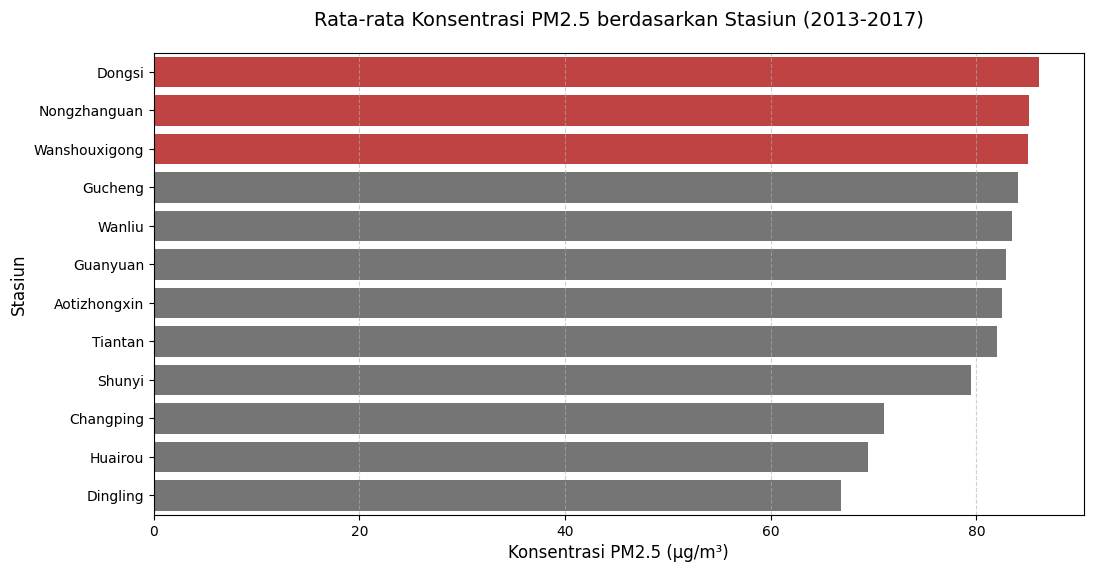

In [42]:
# 1. Menyiapkan data rata-rata PM2.5 per stasiun
# Data diambil dari hasil eksplorasi sebelumnya
pm25_station_data = main_df.groupby('station')['PM2.5'].mean().sort_values(ascending=False).reset_index()

# 2. Membuat visualisasi bar chart
plt.figure(figsize=(12, 6))
colors = ["#D32F2F" if i < 3 else "#757575" for i in range(len(pm25_station_data))] # Merah untuk top 3, abu-abu sisanya

sns.barplot(
    x='PM2.5',
    y='station',
    data=pm25_station_data,
    palette=colors
)

# 3. Menambah keterangan grafik
plt.title('Rata-rata Konsentrasi PM2.5 berdasarkan Stasiun (2013-2017)', fontsize=14, pad=20)
plt.xlabel('Konsentrasi PM2.5 (µg/m³)', fontsize=12)
plt.ylabel('Stasiun', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

**Insight:**
- Stasiun Dongsi, Nongzhanguan, dan Wanshouxigong merupakan tiga wilayah dengan rata-rata konsentrasi PM2.5 tertinggi selama periode 2013-2017.

- Stasiun Dingling mencatat kualitas udara terbaik dengan rata-rata konsentrasi polutan terendah di antara 12 stasiun lainnya.

- Terdapat kesenjangan kualitas udara yang cukup jelas antara wilayah pusat kota (seperti Dongsi) dengan wilayah pinggiran (seperti Dingling dan Huairou).

### Pertanyaan 2:

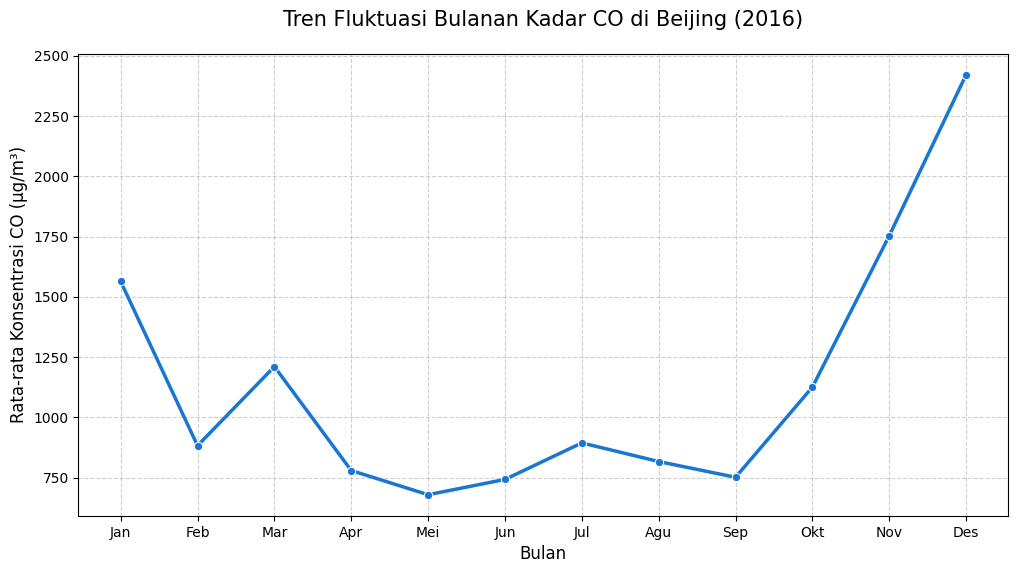

In [43]:
# 1. Memfilter data hanya untuk tahun 2016
df_2016 = main_df[main_df['year'] == 2016]

# 2. Menghitung rata-rata CO per bulan
co_monthly_2016 = df_2016.groupby('month')['CO'].mean().reset_index()

# 3. Membuat visualisasi line chart
plt.figure(figsize=(12, 6))
sns.lineplot(
    x='month',
    y='CO',
    data=co_monthly_2016,
    marker='o',
    linewidth=2.5,
    color='#1976D2' # Biru profesional
)

# Menambahkan detail grafik
plt.title('Tren Fluktuasi Bulanan Kadar CO di Beijing (2016)', fontsize=15, pad=20)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Rata-rata Konsentrasi CO (µg/m³)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des'])
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

**Insight:** (Opsional)
- Kadar polusi Karbon Monoksida ($CO$) di Beijing selama tahun 2016 menunjukkan tren musiman yang sangat kuat, di mana konsentrasi polutan melonjak drastis pada kuartal keempat (Oktober hingga Desember).
- Bulan Desember mencatat puncak konsentrasi tertinggi mencapai lebih dari $2400\ \mu g/m^3$, yang mengindikasikan periode dengan risiko kesehatan paling kritis bagi penduduk.
- Sebaliknya, kualitas udara relatif lebih baik (kadar $CO$ rendah) terjadi pada pertengahan tahun, dengan titik terendah berada pada bulan Mei.
- Peningkatan tajam sejak bulan Oktober hingga Desember memberikan indikasi bagi otoritas terkait untuk meningkatkan kewaspadaan dan memberikan peringatan dini kesehatan kepada warga saat memasuki musim dingin.

## Analisis Lanjutan (Opsional)

Distribusi Kategori Kualitas Udara:
                     aqi_category   count
0                       Unhealthy  145447
1                        Moderate   93056
2                            Good   63928
3                  Very Unhealthy   63856
4  Unhealthy for Sensitive Groups   54481


/tmp/ipykernel_2943/1210068919.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='aqi_category', data=aqi_dist, palette='viridis')


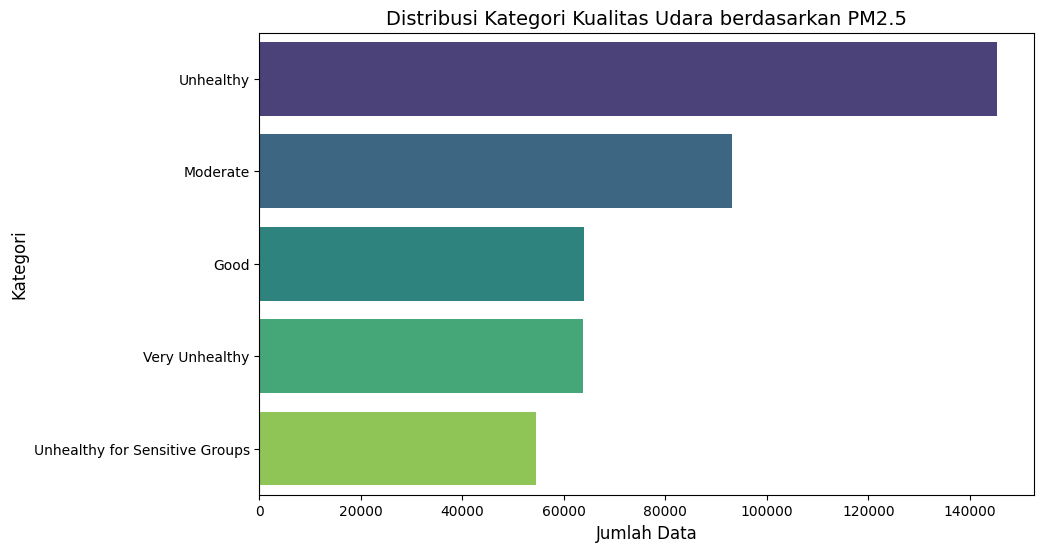

In [44]:
# Membuat fungsi untuk klasifikasi kualitas udara berdasarkan PM2.5 (Standar Sederhana)
def classify_aqi(pm25):
    if pm25 <= 12:
        return 'Good'
    elif pm25 <= 35.4:
        return 'Moderate'
    elif pm25 <= 55.4:
        return 'Unhealthy for Sensitive Groups'
    elif pm25 <= 150.4:
        return 'Unhealthy'
    else:
        return 'Very Unhealthy'

# Menerapkan klasifikasi ke kolom baru
main_df['aqi_category'] = main_df['PM2.5'].apply(classify_aqi)

# Melihat distribusi kategori kualitas udara
aqi_dist = main_df['aqi_category'].value_counts().reset_index()
print("Distribusi Kategori Kualitas Udara:")
print(aqi_dist)

# Visualisasi distribusi AQI
plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='aqi_category', data=aqi_dist, palette='viridis')
plt.title('Distribusi Kategori Kualitas Udara berdasarkan PM2.5', fontsize=14)
plt.xlabel('Jumlah Data', fontsize=12)
plt.ylabel('Kategori', fontsize=12)
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Analisis spasial menunjukkan bahwa stasiun Dongsi dan Nongzhanguan adalah wilayah dengan tingkat polusi $PM_{2.5}$ tertinggi. Perbedaan yang kontras dengan stasiun Dingling (paling bersih) mengindikasikan adanya korelasi antara kepadatan urban/aktivitas industri dengan rendahnya kualitas udara.
- **Conclusion pertanyaan 2:** Tren temporal pada tahun 2016 mengonfirmasi adanya pola musiman yang sangat jelas, di mana kadar $CO$ melonjak drastis pada akhir tahun (puncak di Desember) dan mencapai titik terendah pada musim panas (Mei-Juni).
- **Kesimpulan Umum:** Secara keseluruhan, kualitas udara di 12 stasiun Beijing selama 2013-2017 didominasi oleh kategori Unhealthy, yang menuntut kebijakan penanganan lingkungan yang lebih masif dan terstruktur.

**Rekomendasi Action Item:**
- Intervensi Medis: Mengingat tingginya frekuensi udara "Unhealthy", pemerintah perlu menyediakan fasilitas kesehatan pernapasan yang lebih aksesibel di wilayah-wilayah kritis seperti Dongsi.
- Kebijakan Musiman: Menetapkan aturan pembatasan emisi kendaraan dan industri yang lebih ketat khusus pada kuartal keempat (Oktober-Desember) untuk mengantisipasi lonjakan musiman $CO$.
- Edukasi Publik: Meluncurkan kampanye penggunaan masker N95 atau alat pelindung pernapasan lainnya saat kategori AQI menunjukkan status "Unhealthy", terutama bagi kelompok rentan.